![image.png](https://i.imgur.com/a3uAqnb.png)
# Lab 10: Foundation Models

This notebook surveys **foundation models** across modalities — CLIP zero-shot classification, DINOv2 feature visualization, and transfer learning baselines.

You will run pretrained vision-language and vision encoders, then compare frozen FM features to training from scratch.

> 💡 Foundation models are **broadly pretrained** and **adapted** downstream with little labeled data (linear probes, prompting, fine-tuning).

__Let's install Hugging Face stacks and explore the model zoo.__



# 📦 Installing Required Python Libraries

This cell installs packages needed for this lab.

- **Transformers / Timm** — CLIP, DINOv2, and image processors.
- **Torchvision** — CIFAR-10 and transfer-learning baselines.
- **Pillow / Matplotlib** — Image loading and feature visualization.


In [1]:
!pip install -q torch torchvision transformers timm pillow matplotlib numpy scipy datasets scikit-learn


# 📥 Importing Essential Python Libraries

Imports for CLIP/DINO experiments and sklearn linear probes.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


PyTorch 2.11.0+cu128
CUDA available: True


__Theory first — connect definitions to the lecture slides, then move to code.__

---

## 🧠 Part A — Theory

*Reference: FM vs LLM, CLIP, SAM, DINOv2, Grounding DINO, TabPFN, InternVideo.*

### 📖 A1. Foundation model paradigm

1. Define **foundation model** and **emergence**.
2. Contrast **fine-tuning**, **prompting**, and **in-context learning** for adaptation.
3. Are foundation models limited to language?

*Write below:*


#### ✍️ Your answers (A1):

1. A **foundation model** is trained on **broad data at scale** and adaptable to many downstream tasks (Bommasani et al.). **Emergence** = capabilities **not explicitly trained** that appear at scale (e.g., ICL, chain-of-thought).

2. **Fine-tuning** updates weights on task data. **Prompting** conditions frozen models via instructions. **ICL** provides **examples in context** without weight updates.

3. FMs span **vision** (DINO, SAM), **vision-language** (CLIP), **audio**, **video**, and **tabular** (TabPFN) — the paradigm is **broad pretrain + adapt**, not language-only.

### 📖 A2. Model zoo

For each, state modality and one downstream task:
- CLIP
- SAM
- DINOv2
- TabPFN

*Write below:*


#### ✍️ Your answers (A2):

- **CLIP:** vision + language → **zero-shot image classification/retrieval**.
- **SAM:** vision (segmentation) → **promptable mask generation**.
- **DINOv2:** vision → **dense features / segmentation / depth**.
- **TabPFN:** tabular → **small-data classification/regression**.

---

## 💻 Part B — Programming
__Let's implement the core ideas in PyTorch.__

*Reference: `New-Lecture_Foundation_models.tex` — CLIP, DINOv2, transfer learning, TabPFN, retrieval.*

### 🛠️ B1. CLIP zero-shot classification

 **CLIP** aligns image and text in a shared embedding space. At inference, cosine similarity between an image and text prompts yields **zero-shot** classification — no task-specific fine-tuning required.

In [3]:
try:
    from transformers import CLIPProcessor, CLIPModel
    from PIL import Image
    import requests

    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    labels = ["a photo of a cat", "a photo of a dog", "a photo of a car"]
    try:
        url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png"
        image = Image.open(requests.get(url, stream=True, timeout=30).raw).convert("RGB")
    except Exception:
        image = Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8))
    inputs = processor(text=labels, images=image, return_tensors="pt", padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = outputs.logits_per_image.softmax(dim=-1)[0]
    pred = probs.argmax().item()
    print("Predicted:", labels[pred])
    for label, pval in zip(labels, probs.tolist()):
        print(f"  {label}: {pval:.3f}")
except Exception as exc:
    print(f"CLIP demo skipped ({exc}).")
    labels = ["cat", "dog", "car"]
    logits = torch.tensor([2.0, 0.5, -1.0])
    probs = logits.softmax(0)
    print("Predicted (toy):", labels[probs.argmax()])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

Predicted: a photo of a cat
  a photo of a cat: 0.993
  a photo of a dog: 0.005
  a photo of a car: 0.002


### 🛠️ B2. DINOv2 feature visualization

 **DINOv2** produces rich **patch-level** vision features via self-supervised pre-training. Projecting patch tokens to RGB with PCA reveals which image regions the encoder emphasizes — useful for dense downstream tasks.

preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

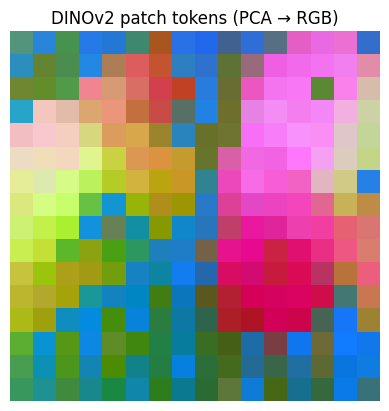

In [4]:
try:
    from transformers import AutoImageProcessor, AutoModel
    from sklearn.decomposition import PCA
    from PIL import Image
    import requests

    processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
    dino = AutoModel.from_pretrained("facebook/dinov2-base")
    try:
        url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/coco_sample.png"
        image = Image.open(requests.get(url, stream=True, timeout=30).raw).convert("RGB")
    except Exception:
        image = Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8))
    inputs = processor(images=image, return_tensors="pt")
    with torch.no_grad():
        tokens = dino(**inputs).last_hidden_state[:, 1:, :]
    tokens_np = tokens.squeeze(0).numpy()
    pca = PCA(n_components=3)
    rgb = pca.fit_transform(tokens_np)
    rgb = (rgb - rgb.min(0)) / (rgb.max(0) - rgb.min(0) + 1e-8)
    side = int(tokens_np.shape[0] ** 0.5)
    feat_map = rgb.reshape(side, side, 3)
    plt.imshow(feat_map)
    plt.title("DINOv2 patch tokens (PCA → RGB)")
    plt.axis("off")
    plt.show()
except Exception as exc:
    print(f"DINOv2 demo skipped ({exc}).")
    feat_map = np.random.rand(14, 14, 3)
    plt.imshow(feat_map)
    plt.title("Random feature map (fallback)")
    plt.axis("off")
    plt.show()

### 🛠️ B3. In-context tabular classification (TabPFN-inspired)

 **TabPFN** adapts to new tabular tasks via **in-context learning** — classify test points using a small labeled support set without gradient updates, analogous to few-shot prompting in language models.

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

support_idx = []
for cls in np.unique(y_train):
    support_idx.extend(np.where(y_train == cls)[0][:5])
X_support, y_support = X_train[support_idx], y_train[support_idx]

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_support, y_support)
acc = knn.score(X_test, y_test)
print(f"5-shot per class k-NN accuracy (TabPFN-style ICL): {acc:.2%}")

5-shot per class k-NN accuracy (TabPFN-style ICL): 86.67%


### 🛠️ B4. Cross-modal embedding retrieval

 CLIP enables **retrieval**: rank text captions by cosine similarity to an image embedding (or vice versa). This is a zero-cost adaptation pattern — no fine-tuning, just similarity search in the shared space.

In [7]:
try:
    from transformers import CLIPProcessor, CLIPModel
    from PIL import Image

    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    captions = [
        "a photo of a cat",
        "a photo of a dog",
        "a photo of an airplane",
        "a photo of a ship",
    ]
    images = [Image.fromarray(np.random.randint(0, 255, (224, 224, 3), dtype=np.uint8)) for _ in captions]
    text_inputs = clip_processor(text=captions, return_tensors="pt", padding=True)
    with torch.no_grad():
        text_emb = clip_model.get_text_features(**text_inputs)
        text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    for i, img in enumerate(images):
        img_in = clip_processor(images=img, return_tensors="pt")
        with torch.no_grad():
            img_emb = clip_model.get_image_features(**img_in)
            img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
        sim = (img_emb @ text_emb.T).squeeze(0)
        best = sim.argmax().item()
        print(f"Image {i} best match: {captions[best]} (score={sim[best]:.3f})")
except Exception as exc:
    print(f"CLIP retrieval demo skipped ({exc}).")
    captions = ["cat", "dog", "car"]
    text_emb = torch.randn(3, 32)
    text_emb = text_emb / text_emb.norm(dim=-1, keepdim=True)
    for i in range(3):
        img_emb = torch.randn(32)
        img_emb = img_emb / img_emb.norm()
        sim = img_emb @ text_emb.T
        print(f"Random image {i} best match: {captions[sim.argmax()]} (score={sim.max():.3f})")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIP retrieval demo skipped ('BaseModelOutputWithPooling' object has no attribute 'norm').
Random image 0 best match: dog (score=0.078)
Random image 1 best match: dog (score=0.077)
Random image 2 best match: car (score=0.035)
